# Wine Quality Prediction

Goal: Build a machine learning model to predict wine quality based on physicochemical features.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import re
import matplotlib.cm as cm
from itertools import permutations

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

from sklearn.preprocessing import RobustScaler  

from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## utility functions

In [3]:
# Define all functions here

def printf_handler(func):
    def inner(*args, **kwargs):
        if len(args) == 1 and isinstance(args[0], (list, tuple)):
            func(*args[0])

        elif len(args) > 1 and not any(isinstance(arg, (list, tuple)) for arg in args):
            func(*args)

        elif len(args) > 1 and any(isinstance(arg, (list, tuple)) for arg in args):
            processed_args = []
            for arg in args:
                if isinstance(arg, (list, tuple)):
                    processed_args.extend(arg)
                else:
                    processed_args.append(arg)
            func(*processed_args)

        else:
            func(*args)
    return inner

@printf_handler
def printf(*args):
    """Print each argument on a new line"""
    for arg in args:
        print(arg, '\n')



## Load Dataset

In [ ]:
path = kagglehub.dataset_download("sumit17125/red-wine-quality-dataset")
df = pd.read_csv(path + "/winequality-red.csv")
df = pd.read_csv(path + "/winequality-red.csv",sep=';')

## Data Overview

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
printf(df.info(),df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0


In [8]:
for col in df.columns:
    print(f"{col} uniques")
    print(df[col].unique(),'\n')

fixed acidity uniques
[ 7.4  7.8 11.2  7.9  7.3  7.5  6.7  5.6  8.9  8.5  8.1  7.6  6.9  6.3
  7.1  8.3  5.2  5.7  8.8  6.8  4.6  7.7  8.7  6.4  6.6  8.6 10.2  7.
  7.2  9.3  8.   9.7  6.2  5.   4.7  8.4 10.1  9.4  9.   8.2  6.1  5.8
  9.2 11.5  5.4  9.6 12.8 11.  11.6 12.  15.  10.8 11.1 10.  12.5 11.8
 10.9 10.3 11.4  9.9 10.4 13.3 10.6  9.8 13.4 10.7 11.9 12.4 12.2 13.8
  9.1 13.5 10.5 12.6 14.  13.7  9.5 12.7 12.3 15.6  5.3 11.3 13.   6.5
 12.9 14.3 15.5 11.7 13.2 15.9 12.1  5.1  4.9  5.9  6.   5.5] 

volatile acidity uniques
[0.7   0.88  0.76  0.28  0.66  0.6   0.65  0.58  0.5   0.615 0.61  0.62
 0.56  0.59  0.32  0.22  0.39  0.43  0.49  0.4   0.41  0.71  0.645 0.675
 0.685 0.655 0.605 0.38  1.13  0.45  0.67  0.52  0.935 0.29  0.31  0.51
 0.42  0.63  0.69  0.735 0.725 0.705 0.785 0.75  0.625 0.3   0.55  1.02
 0.775 0.9   0.545 0.575 0.33  0.54  1.07  0.695 1.33  0.745 1.04  0.715
 0.415 0.34  0.68  0.95  0.53  0.64  0.885 0.805 0.73  0.37  0.835 1.09
 0.57  0.44  0.635 0.82  0.48 

### Conclusion : Data is already cleaned

## Exploratory Data Analysis

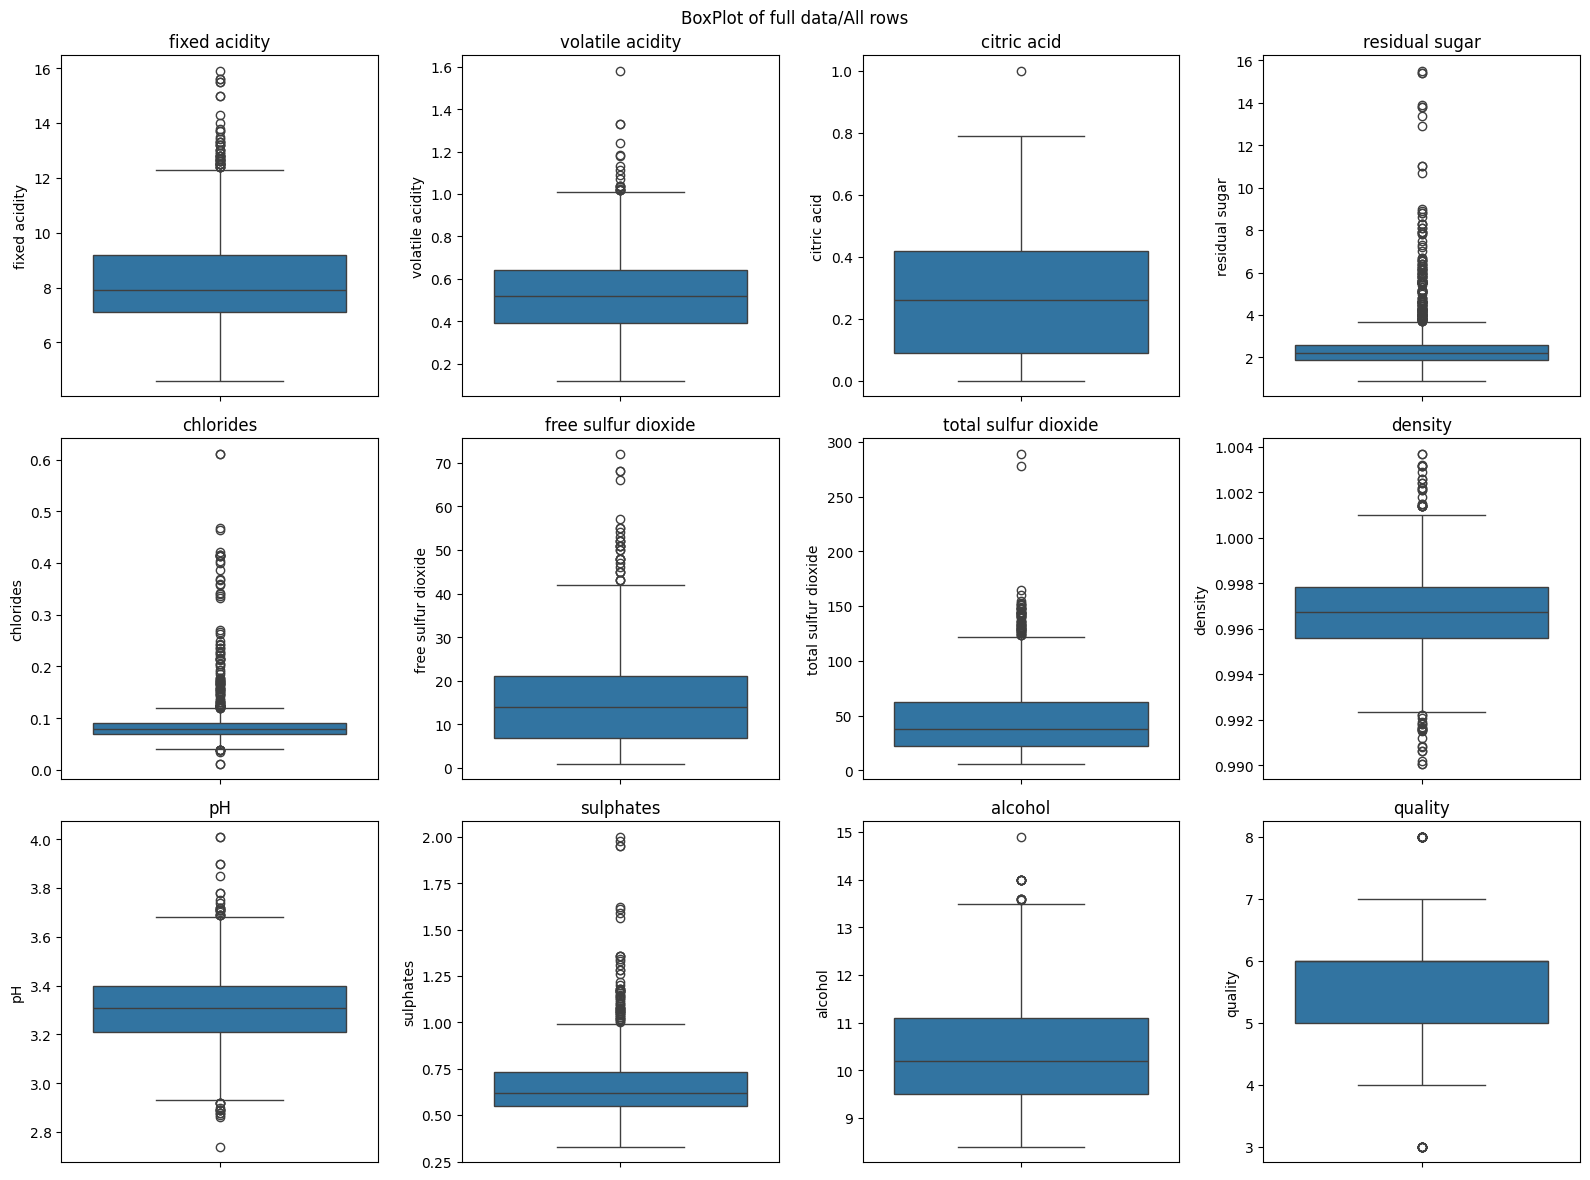

In [12]:
cols = df.columns
n = len(cols)

# grid size
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('BoxPlot of full data/All rows')
plt.tight_layout()
plt.show()

In [ ]:
# There are lots of outliers and each features has different range of values

<Axes: >

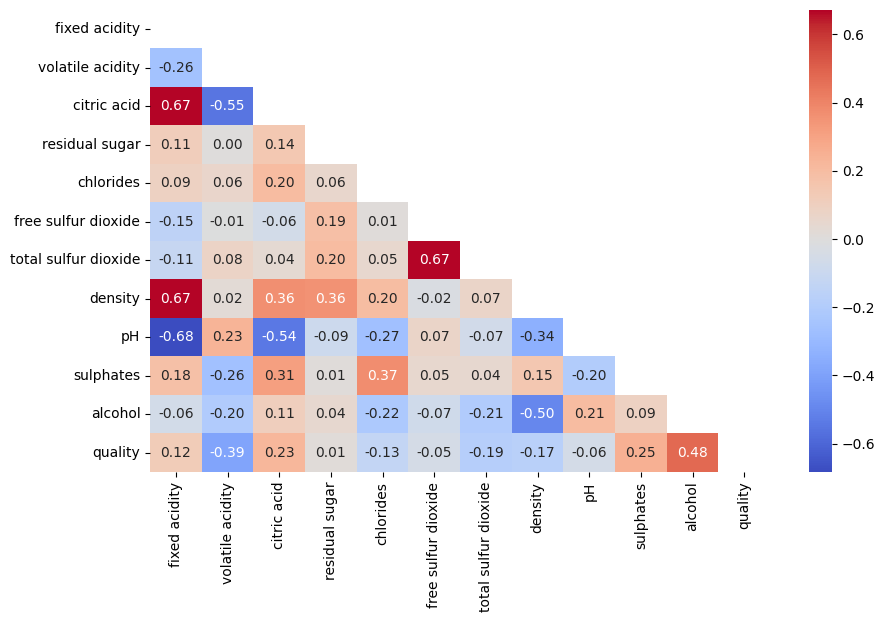

In [13]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
# top 3 features with high corr with quality
# alcohol , volatile acidity , sulphates

In [14]:
# Lets try to find differences in the distribution for top10 percent values vs the bottom90 percent values 
top10percent = int(df.shape[0]*10/100)
i = np.argsort(df['quality'])
df1 = df.iloc[i[df.shape[0] - top10percent:]]
df1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1125,8.8,0.24,0.35,1.7,0.055,13.0,27.0,0.99394,3.14,0.59,11.3,7
1405,7.7,0.28,0.30,2.0,0.062,18.0,34.0,0.99520,3.28,0.90,11.3,7
259,10.0,0.31,0.47,2.6,0.085,14.0,33.0,0.99965,3.36,0.80,10.5,7
1134,8.5,0.28,0.35,1.7,0.061,6.0,15.0,0.99524,3.30,0.74,11.8,7
1133,7.2,0.48,0.07,5.5,0.089,10.0,18.0,0.99684,3.37,0.68,11.2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1090,10.0,0.26,0.54,1.9,0.083,42.0,74.0,0.99451,2.98,0.63,11.8,8
1120,7.9,0.54,0.34,2.5,0.076,8.0,17.0,0.99235,3.20,0.72,13.1,8
588,5.0,0.42,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.0,8
828,7.8,0.57,0.09,2.3,0.065,34.0,45.0,0.99417,3.46,0.74,12.7,8


In [15]:
df2 = df.iloc[i[:df.shape[0] - top10percent]]
df2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
832,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
517,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
899,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3
459,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1147,10.0,0.410,0.45,6.20,0.071,6.0,14.0,0.99702,3.21,0.49,11.8,7
1157,5.1,0.510,0.18,2.10,0.042,16.0,101.0,0.99240,3.46,0.87,12.9,7
1156,8.5,0.180,0.51,1.75,0.071,45.0,88.0,0.99524,3.33,0.76,11.8,7
443,10.0,0.440,0.49,2.70,0.077,11.0,19.0,0.99630,3.23,0.63,11.6,7


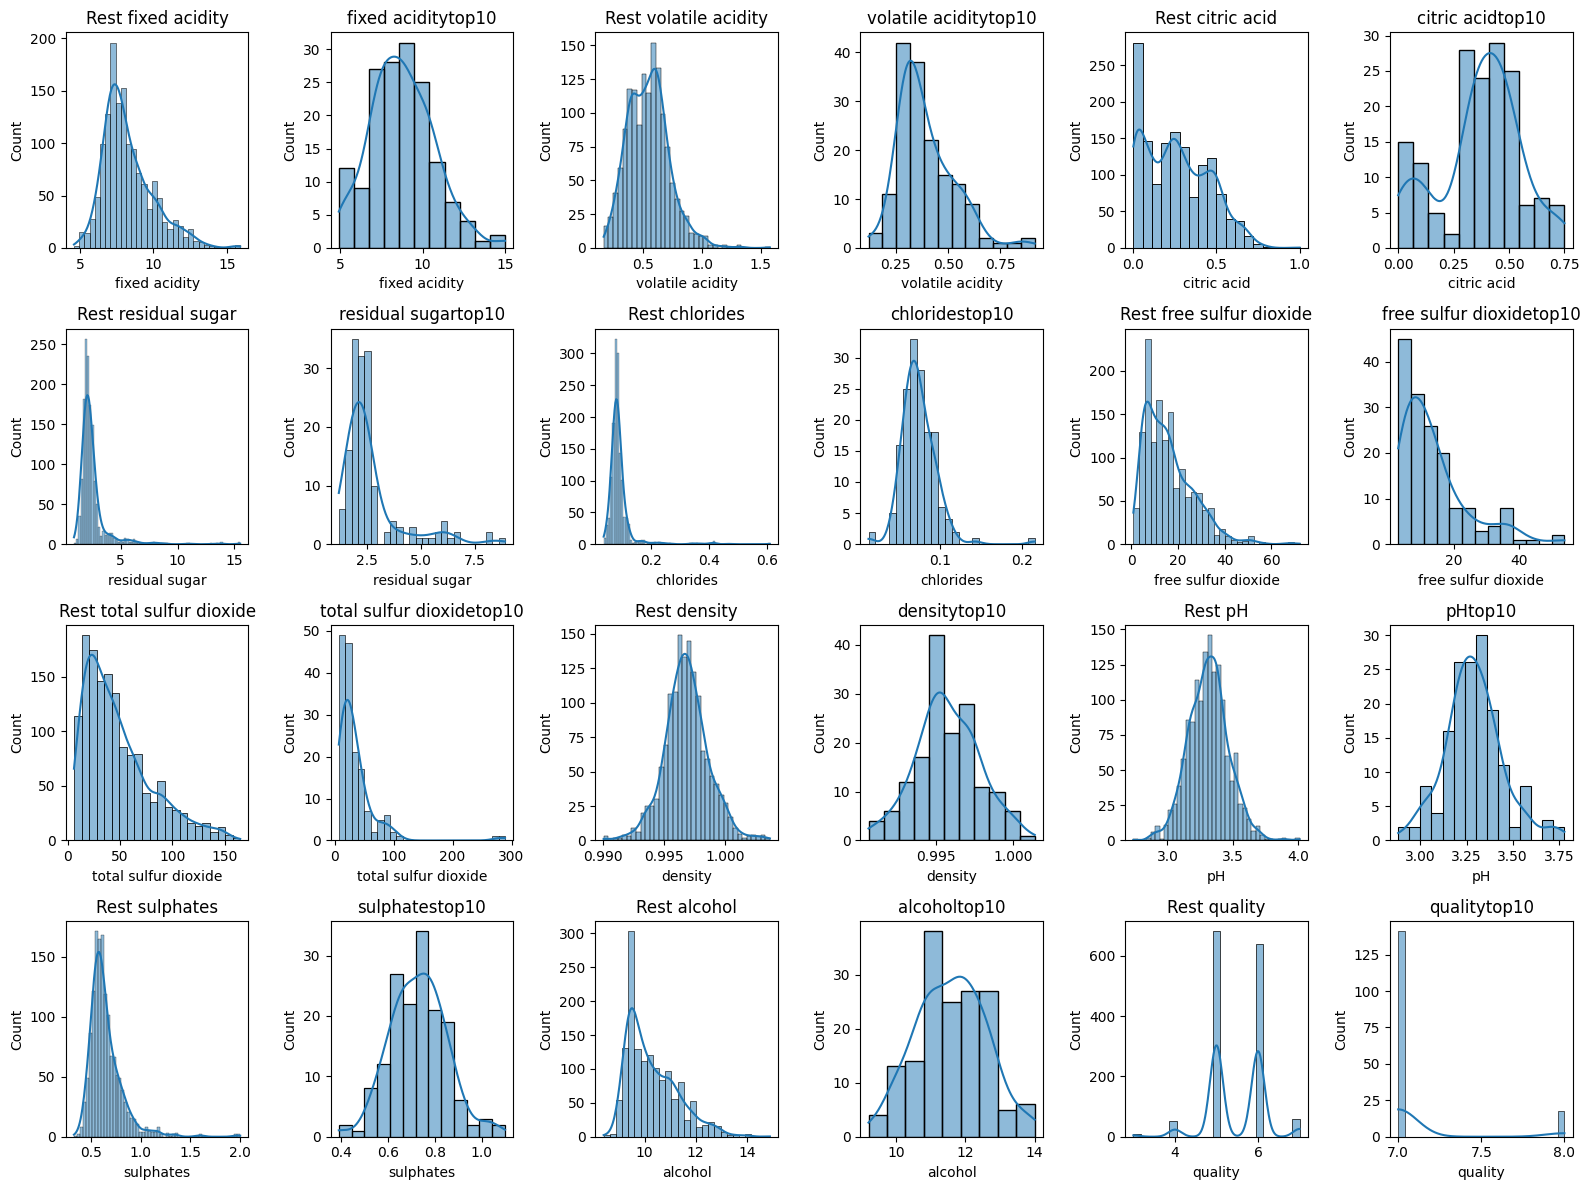

In [ ]:
n = len(df.columns)

n_cols = 6
n_rows = 2*int(np.ceil(n/n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(16,3*n_rows))

axes = axes.flatten()

for i,col in zip(np.arange(0,24,2),df.columns):
    sns.histplot(x=df2[col], ax=axes[i],kde=True)
    axes[i].set_title(f"Rest {col}")
    sns.histplot(x=df1[col],ax=axes[i+1],kde=True)
    axes[i+1].set_title(f"{col}top10")

#for j in range(i+1,len(axes)):
#    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
td = df.groupby('quality')

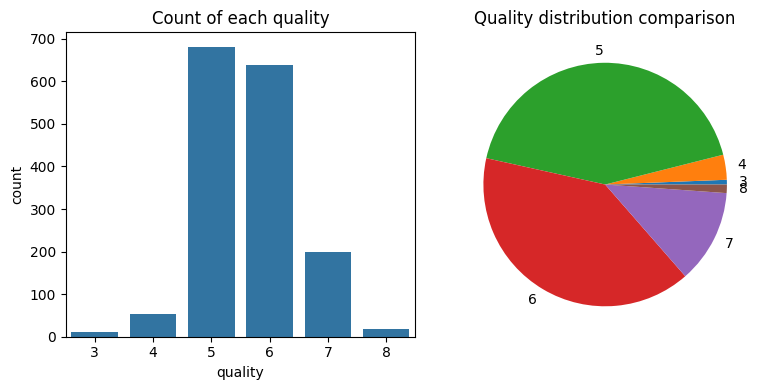

In [ ]:
# Checking the count and distribution comparison of all the quality entries 
n_cols = 2
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8,4))
axes = axes.flatten()

sns.countplot(x=df['quality'], ax=axes[0])
axes[0].set_title("Count of each quality")

axes[1].pie(td.size(), labels=td.size().index)
axes[1].set_title("Quality distribution comparison")

plt.tight_layout()
plt.show()

In [ ]:
df3 = td.agg(['mean','var'])
df3['alcohol']

,mean,var
quality,,
3,9.955000,0.669139
4,10.265094,0.873806
5,9.899706,0.542463
6,10.629519,1.101742
7,11.465913,0.925315
8,12.094444,1.498203


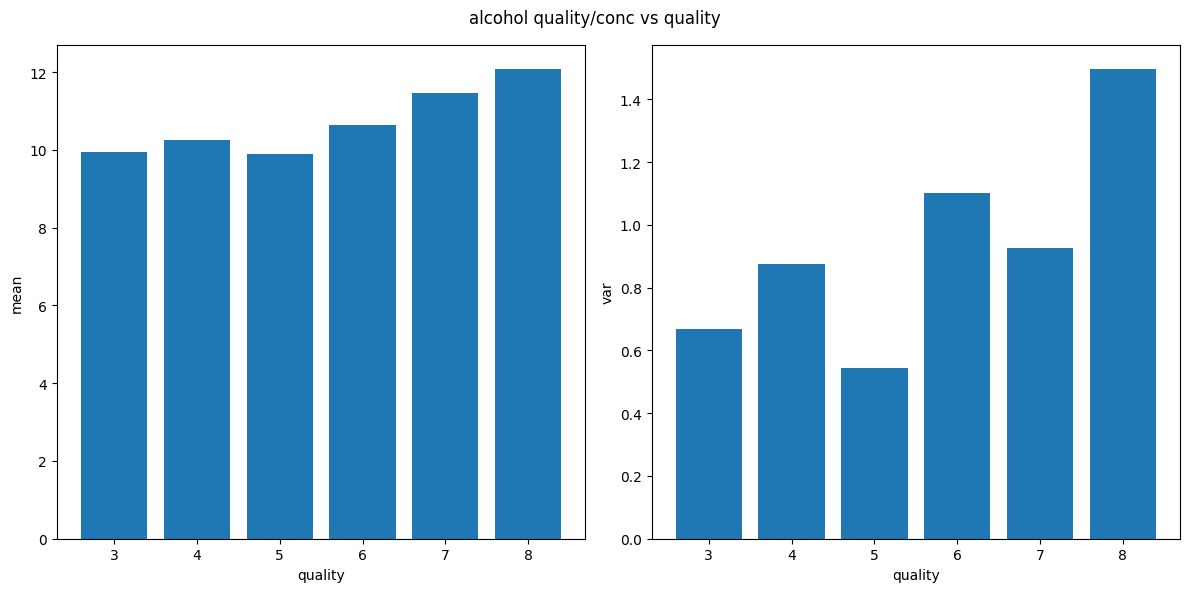

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

for i in range(2):
    axes[i].bar(df3.index,df3['alcohol'].iloc[:,i])
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(df3['alcohol'].columns[i])

fig.suptitle('alcohol quality/conc vs quality')
plt.tight_layout()
plt.show()
# I see trend in mean and var doesn't have a simple trend


In [ ]:
df4 = td.agg(['median','std'])
df5 = pd.DataFrame({
"mean/median" : df3['alcohol']['mean'] /df4['alcohol']['median'] ,
"var/std" : df3['alcohol']['var'] /df4['alcohol']['std']
})

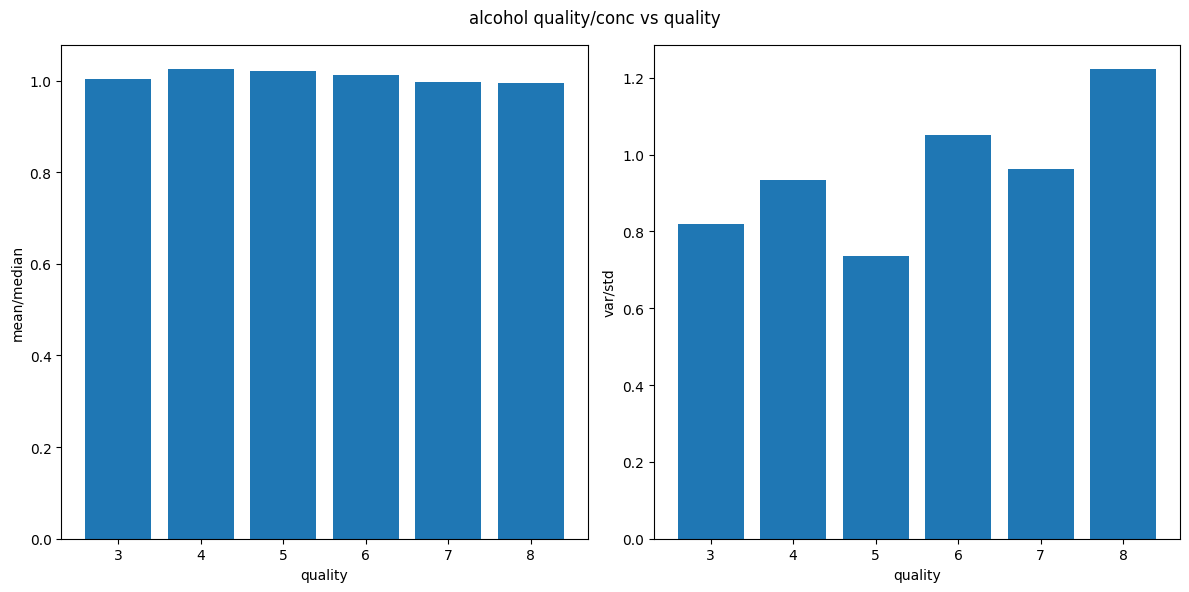

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes = axes.flatten()

for i in range(2):
    axes[i].bar(df5.index,df5.iloc[:,i])
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(df5.columns[i])

fig.suptitle('alcohol quality/conc vs quality')
plt.tight_layout()
plt.show()
# I see trend in mean/median and noisy var/std


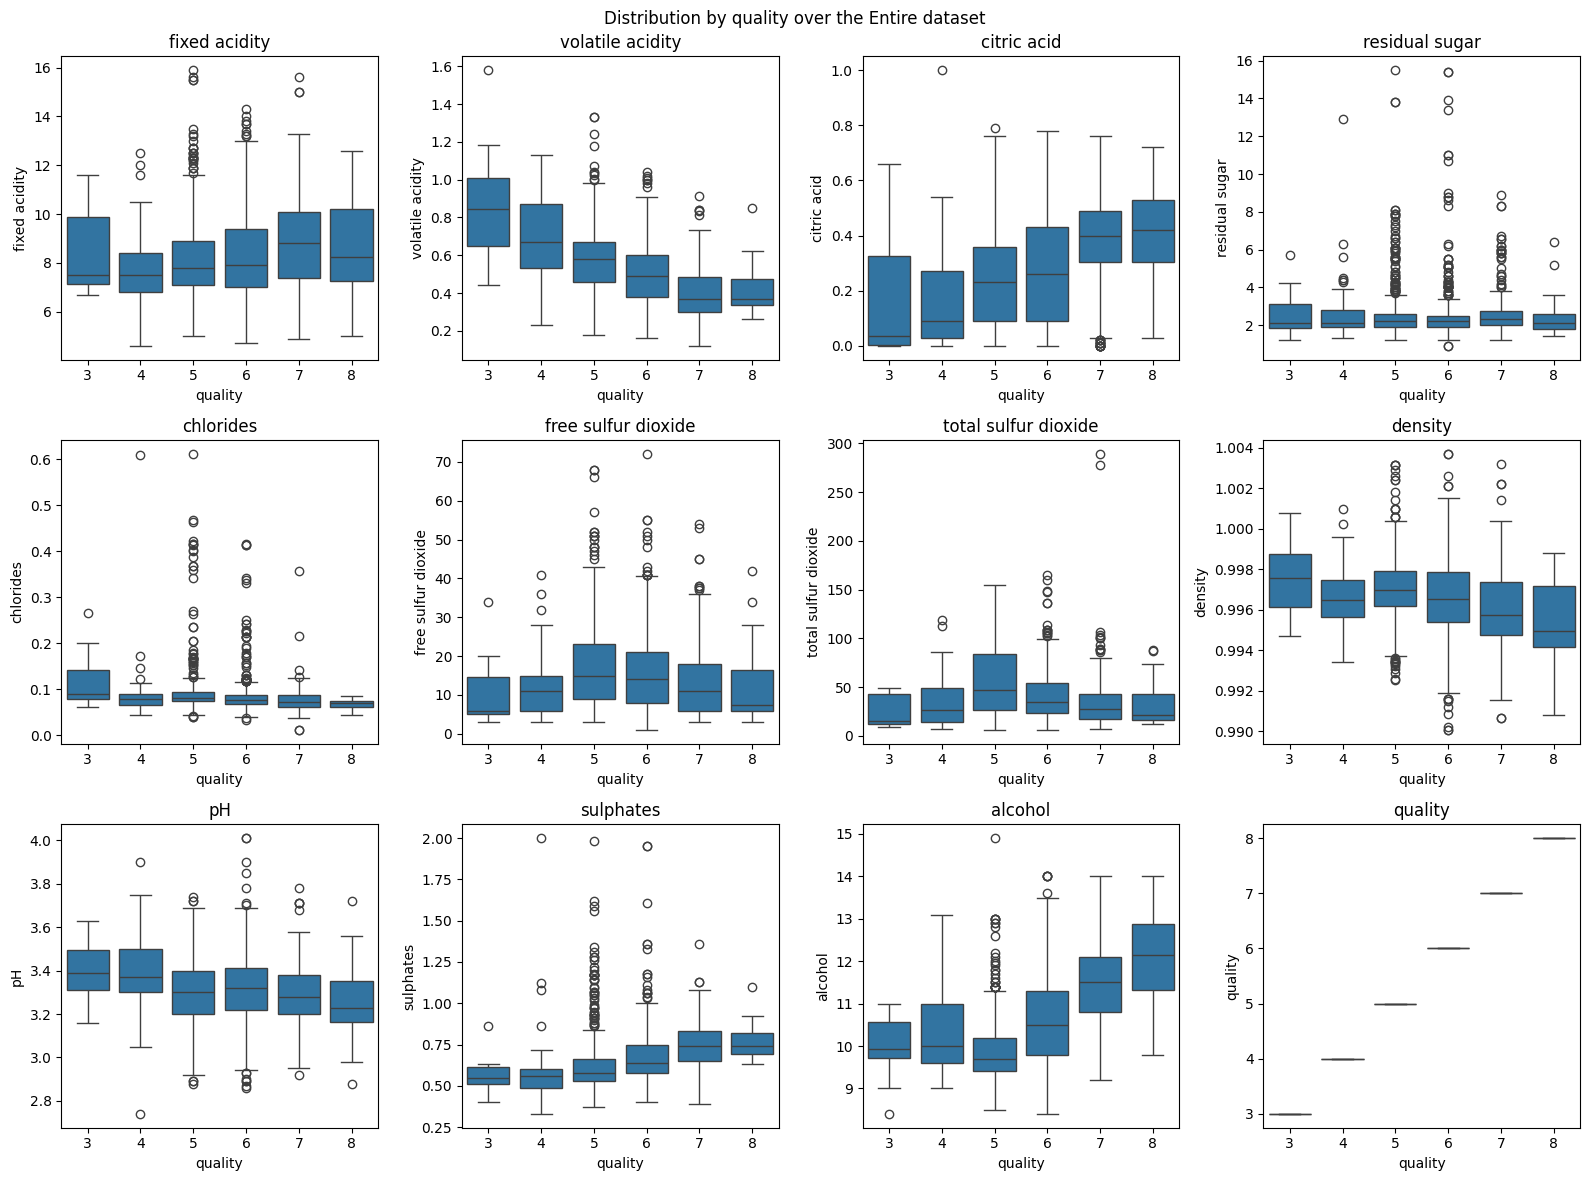

In [16]:
cols = df.columns
n = len(cols)

# grid size
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df['quality'], y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution by quality over the Entire dataset")
plt.tight_layout()
plt.show()

In [ ]:
# Rough note : I have only picked features via comparing histograms for top10 vs bottom90 and checking for linear trends in distribution (boxplot) accross quality
# and correlation for reference 

##### EDA conclusions
Methodology : I see trend I pick

###### Observations :
For histogram ,I checked does the top10% behave differently for than the rest more specifically  I looked at where are the most values (left,center,right) , has it shifted for top10 compared to bottom90 

Which features had the most shift in values in the top 10 

| Columns           |  most values (Rest ~ top10 )          |
| ----------------- | ------------------------------------- |
| Volatile acidity  | {0,1} ~ {0.25,0.50}                 |
| citric acid       | {0.0,0.5} left ~ {0.25,0.60} center |
| residual sugar    | {0,5} left ~ {0,2.5} left           |
| alcohol           | {0,12} left ~ {10,14} center                       |




From boxplots I see that as quality increases Median also increases , Q3 also increases but Q1 doesn't follow this behavior , which imples Higher quality wine tend to have higher feature values, but lower don't follow any single pattern

- volatile acidity : distribution(Q3 - Q1),median consistently decreases till 7 , on 8 median almost stay stable and distribution kinda umm s
shrinks
- citric acid : Median consistently increase , and distribution also almost consistently increases
- chlorides : meadian steadily decrease after quality 5 , damn so many outliers
- free sulphur dioxide : steady decrease in median after quality 5
- total sulphur dioxide : steady decrease in median after quality 5
- density : Median increase till 3-7 then decrease
- sulphates : median steadily increase then stable after quality 4
- alcohol : after quality 4 , the median and the distribution strictly increase ( most stable increase seen yet )
___ 

- fixed acidity : no consistent behavior to report
- residual sugar : Nothing to determine , so many outliers , median is also not showing consistent behavior
- pH : increase decrease nothing to say ( not a linear relation but it does decrease , like 
inclined sinosodial relation )

I pick <br>
>alcohol          ( correlation map , histogram , ...) <br>
>volatile acidity ( correlation map , histogram ) <br>
>citric acid      ( histogram , boxplot ) <br>
>Density          ( boxplot ) 

## Model training

Data transformation included

#### KNN

In [10]:
features = ['alcohol','volatile acidity','citric acid','density']
target = 'quality'

In [11]:
X = df[features]
y = df[target]

In [13]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

param_grid = [
    {'scaler': [StandardScaler(),MinMaxScaler(),RobustScaler()],
     'knn__n_neighbors':list(range(1,31)),
     'knn__weights':['uniform','distance'],
     'knn__metric':['euclidean','manhattan','minkowski'],
     'knn__p':[1,2],
     'knn__algorithm':['auto','ball_tree','kd_tree','brute'],
     'knn__leaf_size':[10,20,30,40]}
]

grid = GridSearchCV(pipe,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    verbose=1
                    )

grid.fit(X_train, y_train)

print("Best Params:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

print("Test accuracy:", grid.score(X_test,y_test))

Fitting 5 folds for each of 17280 candidates, totalling 86400 fits
Best Params: {'knn__algorithm': 'auto', 'knn__leaf_size': 10, 'knn__metric': 'euclidean', 'knn__n_neighbors': 22, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': RobustScaler()}
Best CV Score: 0.6544577205882354
Test accuracy: 0.65625
